# Lab Instructions

Create 3 visualizations from text data of your choice.  Each visualization should have at least 1 - 2 sentences explaining both the figure and the interpretation.
You may use any LLM and produce whatever visuals you think best illustrate your data.  

In [1]:
import pandas as pd

df = pd.read_csv('Starbucks_reviews.csv')

df.head()

,name,location,Date,Rating,Review,Image_Links
0,Helen,"Wichita Falls, TX","Reviewed Sept. 13, 2023",5.0,Amber and LaDonna at the Starbucks on Southwes...,['No Images']
1,Courtney,"Apopka, FL","Reviewed July 16, 2023",5.0,** at the Starbucks by the fire station on 436...,['No Images']
2,Daynelle,"Cranberry Twp, PA","Reviewed July 5, 2023",5.0,I just wanted to go out of my way to recognize...,['https://media.consumeraffairs.com/files/cach...
3,Taylor,"Seattle, WA","Reviewed May 26, 2023",5.0,Me and my friend were at Starbucks and my card...,['No Images']
4,Tenessa,"Gresham, OR","Reviewed Jan. 22, 2023",5.0,I’m on this kick of drinking 5 cups of warm wa...,['https://media.consumeraffairs.com/files/cach...


# Visualizations
* Positive/ Negative most used words (Word Cloud)
* Most Positive Reviews by Location (Top 5)/ Most Negative Reviews by Location (Top 5) (Bar Plot)
* Top 20 most used words in positive/ negative reviews (Bar plot)

Positive Reviews


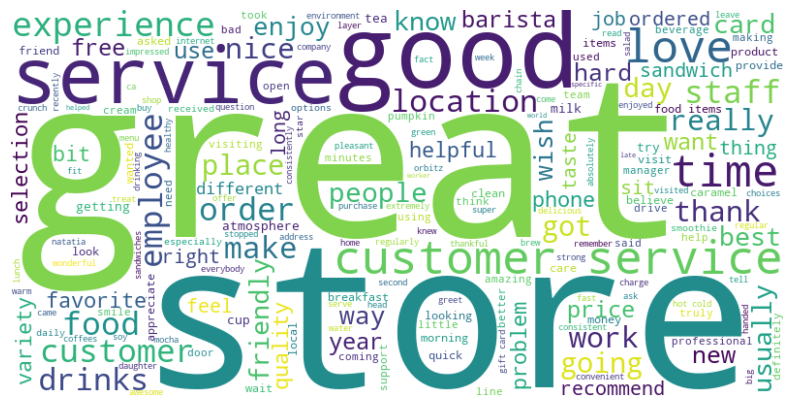

Negative Reviews


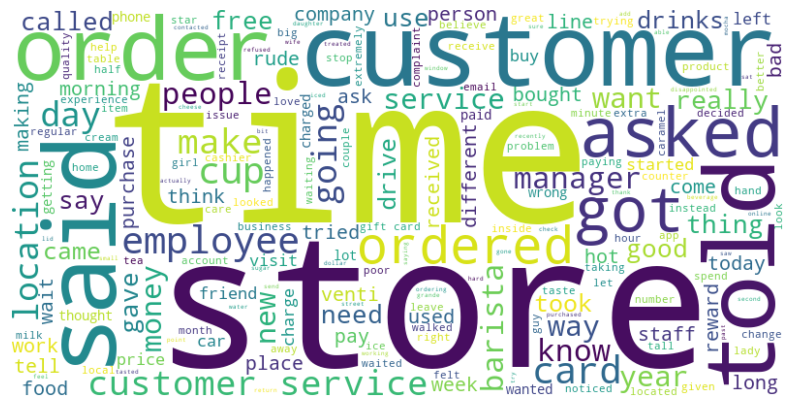

In [23]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
from textblob import TextBlob
import string
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as sklearn_stop_words

# fix dates
clean_date = (
    df['Date'].astype(str)
      .str.replace(r'^Reviewed\s+', '', regex=True)          # remove "Reviewed "
      .str.replace(r'([A-Za-z]{3,})\.', r'\1', regex=True)   # "Sept." -> "Sept"
      .str.strip()
)
d1 = pd.to_datetime(clean_date, format="%b %d, %Y", errors="coerce")
d2 = pd.to_datetime(clean_date, format="%B %d, %Y", errors="coerce")
df['Date'] = d1.fillna(d2)

# keep rows with text
df = df.dropna(subset=['Review']).copy()

# sentiment
df['Rating'] = (df['Rating'].astype(str).str.extract(r'(\d+\.?\d*)')[0].astype(float))
df = df.dropna(subset=['Rating'])
df['Sentiment_Label'] = df['Rating'].apply(lambda x: 'Positive' if x > 3.0 else 'Negative')

# additional stopwords
additional_stopwords = {
    'starbucks',   # brand name
    'coffee', 
    'latte', 
    'frappuccino',
    'like',
    'drink',
    'went'
}
custom_stopwords = sklearn_stop_words.union(additional_stopwords)

# Separate positive and negative reviews
positive_reviews = " ".join(df.loc[df['Sentiment_Label'] == 'Positive', 'Review'].astype(str))
negative_reviews = " ".join(df.loc[df['Sentiment_Label'] == 'Negative', 'Review'].astype(str))

# Tokenize
positive_words = positive_reviews.lower().split()
negative_words = negative_reviews.lower().split()

# Remove punctuation and stopwords
positive_words = [
    w.strip(string.punctuation)
    for w in positive_words
    if w.isalnum() and w not in sklearn_stop_words and w not in additional_stopwords
]

negative_words = [
    w.strip(string.punctuation)
    for w in negative_words
    if w.isalnum() and w not in sklearn_stop_words and w not in additional_stopwords
]

# Generate word clouds
print("Positive Reviews")
wc_pos = WordCloud(width=800, height=400, background_color='white').generate(" ".join(positive_words))
plt.figure(figsize=(10, 7))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.show()

print("Negative Reviews")
wc_neg = WordCloud(width=800, height=400, background_color='white').generate(" ".join(negative_words))
plt.figure(figsize=(10, 7))
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off')
plt.show()

# Word cloud for positive and negative reviews
I used the already supplied Starbucks_reviews.csv. In this csv the ratings are based on stars so I asked a friend who owns a restaurant what they consider a good review and he said anything over a 3 star is good to him, so I used all the reviews over a 3.0 as a "positive" and anything less than or equal to 3.0 as "negative". Based on the word clouds, you can see the most used words for positive reviews are great and store. With negative reviews it appears to be store and time.

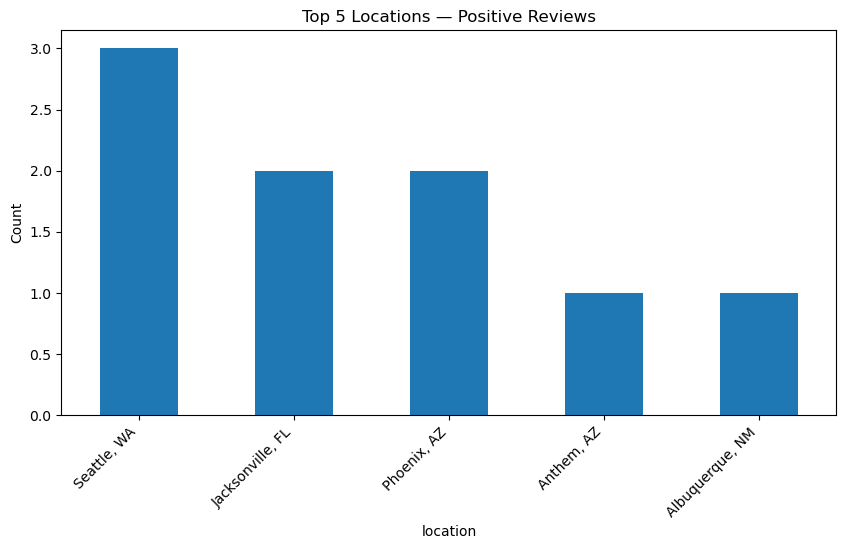

In [27]:
# Clean locations, then count by sentiment
df_loc = df.dropna(subset=['location']).copy()
df_loc['location'] = df_loc['location'].astype(str).str.strip()

pos_top = (
    df_loc[df_loc['Sentiment_Label'] == 'Positive']
    .groupby('location').size()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(10,5))

# Positive
pos_top.plot(kind='bar')
plt.title('Top 5 Locations — Positive Reviews')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

# Top 5 Most Positively Reviewed Locations
This graph actually surprised me, I didn't think Seattle would be the most positively reviewed location with only 3 positive reviews. That being said I also didn't expect 2 of the top 5 to only have 1 positive review. I definitely expected the top 5 locations to have at least 10 positive reviews each.

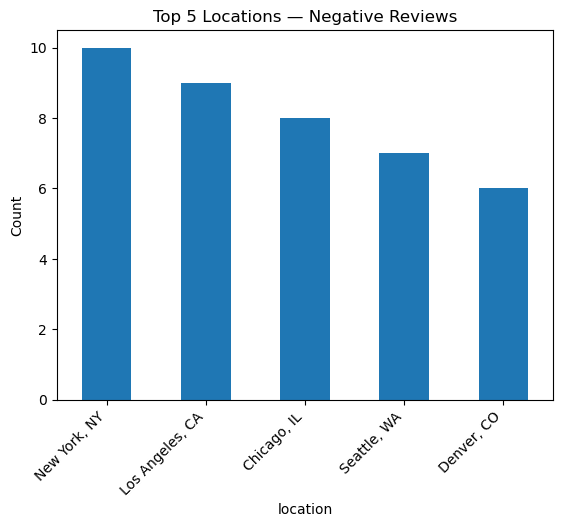

In [25]:
neg_top = (
    df_loc[df_loc['Sentiment_Label'] == 'Negative']
    .groupby('location').size()
    .sort_values(ascending=False)
    .head(5)
)

neg_top.plot(kind='bar')
plt.title('Top 5 Locations — Negative Reviews')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

plt.show()

# Top 5 Most Negatively Reviewed Locations
I expected the negative reviews to be higher than the positive, but not by this much. Looking at the graph I also see Seattle again and it has 7 negative reviews. That means it has only has 3 positive reviews to its 7 negative reviews.

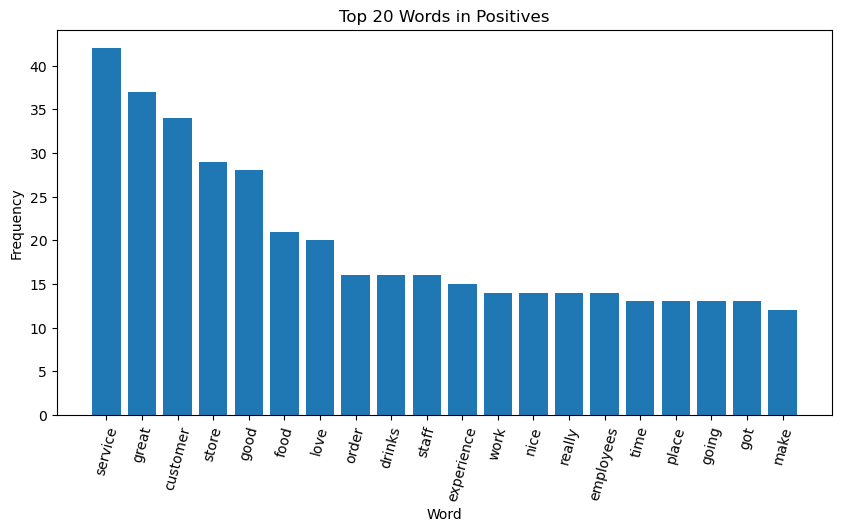

In [39]:
positive_word_freq = Counter(positive_words)
positive_common_words = positive_word_freq.most_common(20)
    
# Convert to DataFrame for plotting
positive_freq_df = pd.DataFrame(positive_common_words, columns=['Word', 'Frequency'])
    
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(positive_freq_df['Word'], positive_freq_df['Frequency'])
ax.set_title(f'Top 20 Words in Positive Reviews')
ax.set_xlabel('Word')
ax.set_ylabel('Frequency')
plt.xticks(rotation=75)
plt.show()

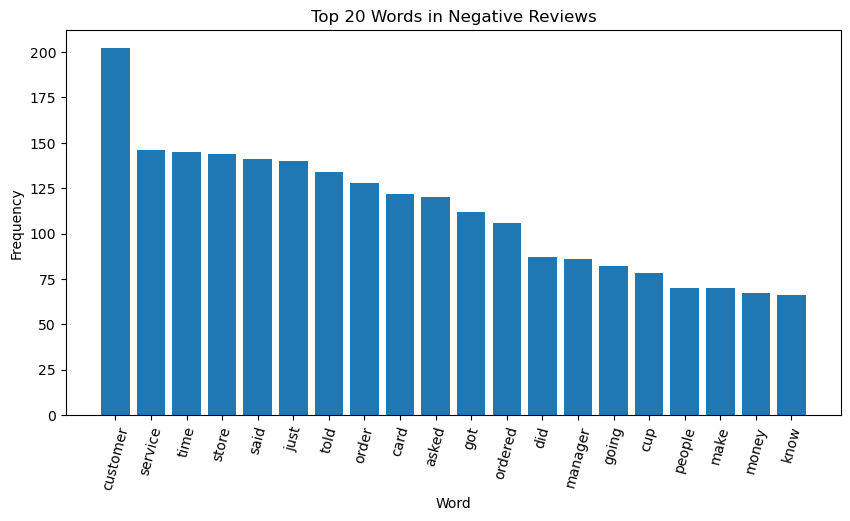

In [40]:
negative_word_freq = Counter(negative_words)
negative_common_words = negative_word_freq.most_common(20)
    
# Convert to DataFrame for plotting
negative_freq_df = pd.DataFrame(negative_common_words, columns=['Word', 'Frequency'])
    
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(negative_freq_df['Word'], negative_freq_df['Frequency'])
ax.set_title(f'Top 20 Words in Negative Reviews')
ax.set_xlabel('Word')
ax.set_ylabel('Frequency')
plt.xticks(rotation=75)
plt.show()

# Top 20 most used words in Positive/Negative reviews
There seems to be some overlap with both positive and negative reviews such as customer and service. Both are within the top 3 on each chart. This isn't at all surprising when you think about it, the business itself is based on customer service, so you'll either have really good customer service or really bad, which would be mentioned in both positive and negative reivews.